# Hyperparameter Optimisation with Optuna — VAE & TransformerVAE

We use **Optuna's NSGA-II sampler** — a multi-objective evolutionary algorithm — to jointly
optimise reconstruction quality and latent-space structure. This gives us a Pareto front rather
than a single scalar optimum, letting us see the trade-off explicitly.

**Why this matters for our project:** our choice of `latent_dim` and `beta` directly affects the
quality of latent representations and, downstream, the drift scores we feed into the SIRC
compartmental model. A principled search gives us evidence that our hyperparameters are
near-optimal — not just eyeballed.

**Reference:** Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019).
*Optuna: A Next-generation Hyperparameter Optimization Framework*. KDD.

**Studies in this notebook:**
1. **Joint latent_dim × beta sweep** (VAE) — the two params that matter most for representation quality
2. **Downstream drift sensitivity** — shows the choice affects epidemiological validity, not just reconstruction
3. **TransformerVAE architecture sweep** — justifies d_model, nhead, num_layers

**Note:** We removed the old DiffAE branch from the cleaned submission because it is not part of the final model comparison.
It has fundamentally different training dynamics — noise prediction MSE, not reconstruction
cross-entropy — so the same objective function does not apply.

In [1]:
import os
if not os.path.exists('models'):
    !git clone https://github.com/sidms24/AML.git
    os.chdir('AML')
!pip install -q -r requirements.txt

Cloning into 'AML'...
remote: Enumerating objects: 553, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 553 (delta 61), reused 4 (delta 4), pack-reused 454 (from 2)
Receiving objects: 100% (553/553), 22.22 MiB | 8.45 MiB/s, done.
Resolving deltas: 100% (331/331), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 11.6 MB/s eta 0:00:00


## Setup

In [2]:
import torch, numpy as np, pandas as pd
import optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history, plot_param_importances,
    plot_slice, plot_contour
)
import tqdm
import tqdm.auto
tqdm.auto.tqdm = tqdm.tqdm
import joblib, warnings, os
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
from scipy.stats import rankdata
from utils.dataloader import load_data, _collate_mixed
from utils.encoders import dna_one_hot
from utils.param_sweep import run_vae_sweep, run_tvae_sweep
from utils.drift import compute_drift_scores
from utils.inference import extract_latents
from utils.loss import VAE_Loss
from utils.train import VAE_train
from models import TransformerVAE, VAE
from utils.sweep_config import TVAE_FIXED
from scipy.stats import spearmanr, rankdata
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True

os.makedirs('results', exist_ok=True)

Device: cuda


In [3]:
# we use H1N1_global for the ablation — same dataset as the main training notebook
h1n1_data = load_data(subtype='H1N1_global', encoder=dna_one_hot, batch_size=512)
h1n1_train, h1n1_test = h1n1_data()

sample_x, _ = next(iter(h1n1_train))
INPUT_DIM = sample_x.shape[1]
SEQ_LENGTH = sample_x.shape[2]
print(f'H1N1 — input_dim={INPUT_DIM}, seq_length={SEQ_LENGTH}, '
      f'train batches={len(h1n1_train)}, test batches={len(h1n1_test)}')

Map (num_proc=4): 100%|██████████| 6245/6245 [00:01<00:00, 4535.70 examples/s]


H1N1 — input_dim=5, seq_length=1759, train batches=49, test batches=13


## Study 1: Joint latent_dim × beta sweep (VAE)

The two hyperparameters that most affect our downstream task are:

- **`latent_dim`** — controls the capacity of the latent space. Too small → can't capture
  variation between seasons. Too large → curse of dimensionality makes L2 drift distances meaningless.
- **`beta`** (KL weight) — controls the trade-off between reconstruction quality and latent
  space regularity. Too low → unstructured latent space. Too high → posterior collapse where
  the encoder ignores the input.

We search these **jointly** because they interact: a small latent space can tolerate higher
beta (the regularisation pressure is spread across fewer dimensions), while a large latent
space may need lower beta to avoid wasting capacity.

All other hyperparameters are **fixed** to their production values for a fair comparison.
We train for 40 epochs (vs 80 in production) since we care about relative ordering, not
absolute best performance.

In [ ]:
tvae_study = run_tvae_sweep(
    h1n1_train,
    h1n1_test,
    input_dim=INPUT_DIM,
    seq_length=SEQ_LENGTH,
    device=device,
)
joblib.dump(tvae_study, 'results/optuna_study_tvae.pkl')
print(f'Saved study with {len(tvae_study.trials)} trials.')

In [ ]:
# results table — filter out diverged trials
rows = []
for t in tvae_study.trials:
    if t.values[0] == float('inf'):
        continue
    beta_val = t.params.get('beta', np.nan)
    test_kl = t.user_attrs.get('test_kl', np.nan)
    test_recon = t.user_attrs.get('test_recon', t.values[0])

    rows.append({
        'trial': t.number,
        'latent_dim': t.params.get('latent_dim', t.user_attrs.get('latent_dim')),
        'beta': round(beta_val, 3) if not np.isnan(beta_val) else np.nan,
        'd_model': t.user_attrs.get('d_model', t.params.get('d_model')),
        'num_layers': t.user_attrs.get('num_layers', t.params.get('num_layers')),
        'dim_feedforward': t.user_attrs.get('dim_feedforward', t.params.get('dim_feedforward')),
        'num_memory_tokens': t.user_attrs.get('num_memory_tokens', t.params.get('num_memory_tokens')),
        'dropout': t.params.get('dropout'),
        'lr': t.params.get('lr'),
        'test_recon': round(test_recon, 4) if not np.isnan(test_recon) else np.nan,
        'silhouette': round(-t.values[1], 4),
        'test_kl': round(test_kl, 4) if not np.isnan(test_kl) else np.nan,
        'kl_collapsed': t.user_attrs.get('kl_collapsed'),
        'epochs': t.user_attrs.get('epochs_trained'),
        'test_loss': round(test_recon + beta_val * test_kl, 4)
                    if not (np.isnan(test_recon) or np.isnan(beta_val) or np.isnan(test_kl))
                    else np.nan,
    })
df_tvae = pd.DataFrame(rows).sort_values('test_recon')
df_tvae.to_csv('results/optuna_tvae_results.csv', index=False)
df_tvae

,trial,latent_dim,beta,d_model,num_layers,dim_feedforward,num_memory_tokens,dropout,lr,test_recon,silhouette,test_kl,kl_collapsed,epochs,test_loss
3,3,128,0.039,128,3,512,8,0.0,0.000180,31.6638,-0.1090,71.8969,False,40,34.4610
5,5,128,0.058,128,2,512,8,0.0,0.000307,34.5038,-0.1913,38.0132,False,40,36.7055
1,1,32,0.021,128,2,512,4,0.1,0.000215,35.8652,-0.1869,53.6333,False,40,36.9736
2,2,128,0.075,128,2,512,8,0.1,0.000202,36.4903,-0.1565,38.8187,False,40,39.3840
9,9,64,0.076,128,2,512,8,0.1,0.000349,37.3856,-0.2896,26.9123,False,40,39.4402
6,6,128,0.049,64,3,256,8,0.0,0.000358,37.5950,-0.1407,46.0448,False,40,39.8401
8,8,32,0.074,64,3,256,8,0.0,0.000279,39.4170,-0.1593,49.7491,False,40,43.1229
4,4,32,0.020,64,2,256,8,0.0,0.000338,40.0638,-0.1776,97.1607,False,40,41.9707
11,11,32,0.014,64,3,256,4,0.0,0.000242,42.8413,-0.1247,116.0600,False,40,44.5049
10,10,32,0.112,128,3,512,4,0.1,0.000386,43.1813,-0.2162,10.3019,False,40,44.3338


In [ ]:
# Pareto front — these are the non-dominated trials
print(f'Pareto front: {len(tvae_study.best_trials)} trials')
for t in tvae_study.best_trials:
    print(f"  #{t.number}: latent_dim={t.params['latent_dim']}, "
          f"beta={t.params['beta']:.3f}, recon={t.values[0]:.4f}, "
          f"sil={-t.values[1]:.4f}, "
          f"d_model={t.params['d_model']}, total_loss={round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0]:.4f}, "
          f"num_memory_tokens={t.params['num_memory_tokens']}, dropout={t.params['dropout']}, "
          f"lr={t.params['lr']}, num_layers={t.params['num_layers']}")


Pareto front: 1 trials
  #3: latent_dim=128, beta=0.039, recon=31.6638, sil=-0.1090, d_model = 128, 
total_loss = (34.46781857079414,), Num_memory_tokens = 8, Dropout =  0.0, lr = 0.00017981813007388224, num layers = 3


### Optimisation history
Shows convergence — are later trials finding better configs?

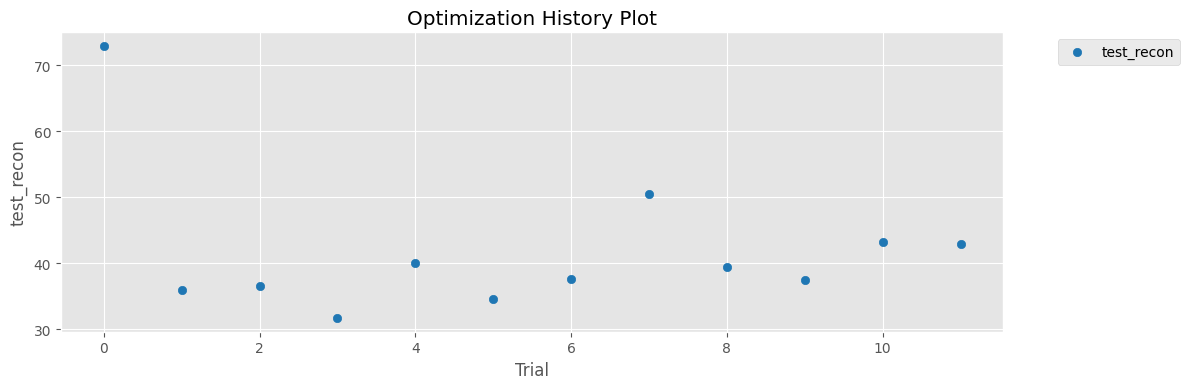

In [ ]:
plot_optimization_history(tvae_study, target=lambda t: t.values[0],
                          target_name='test_recon')
fig = plt.gcf()
fig.set_size_inches(12, 4)
plt.savefig('results/tvae_history.png', dpi=150, bbox_inches='tight')

### Parameter importances
If `latent_dim` dominates, that validates our focus on it as the key capacity knob.
If `beta` dominates, it suggests the KL regularisation weight matters more than raw capacity.

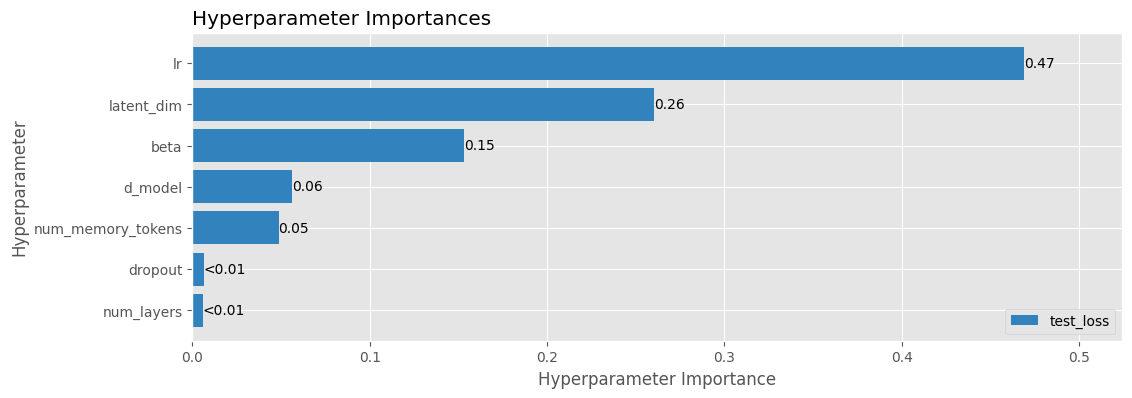

In [ ]:
plot_param_importances(tvae_study, target=lambda t: t.values[0],
                       target_name='test_loss')
fig = plt.gcf()
fig.set_size_inches(12, 4)
plt.savefig('results/tvae_param_importances.png', dpi=150, bbox_inches='tight')

### Contour plot
Shows the interaction surface between `latent_dim` and `beta`. Look for:
- Is there a clear sweet spot?
- Do high beta + low latent_dim cause posterior collapse?

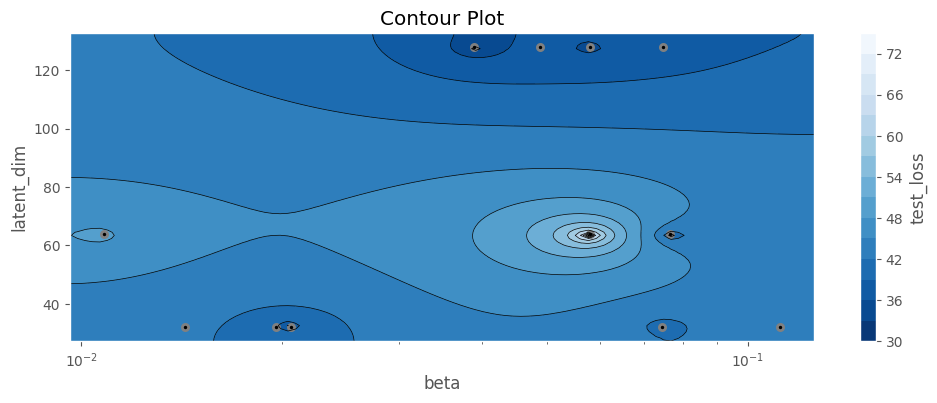

In [ ]:
plot_contour(tvae_study, params=['latent_dim', 'beta'],
             target=lambda t: t.values[0], target_name='test_loss')
fig = plt.gcf()
fig.set_size_inches(12, 4)
plt.savefig('results/tvae_contour_latent_beta.png', dpi=150, bbox_inches='tight')

### Slice plot
Marginal effect of each parameter.

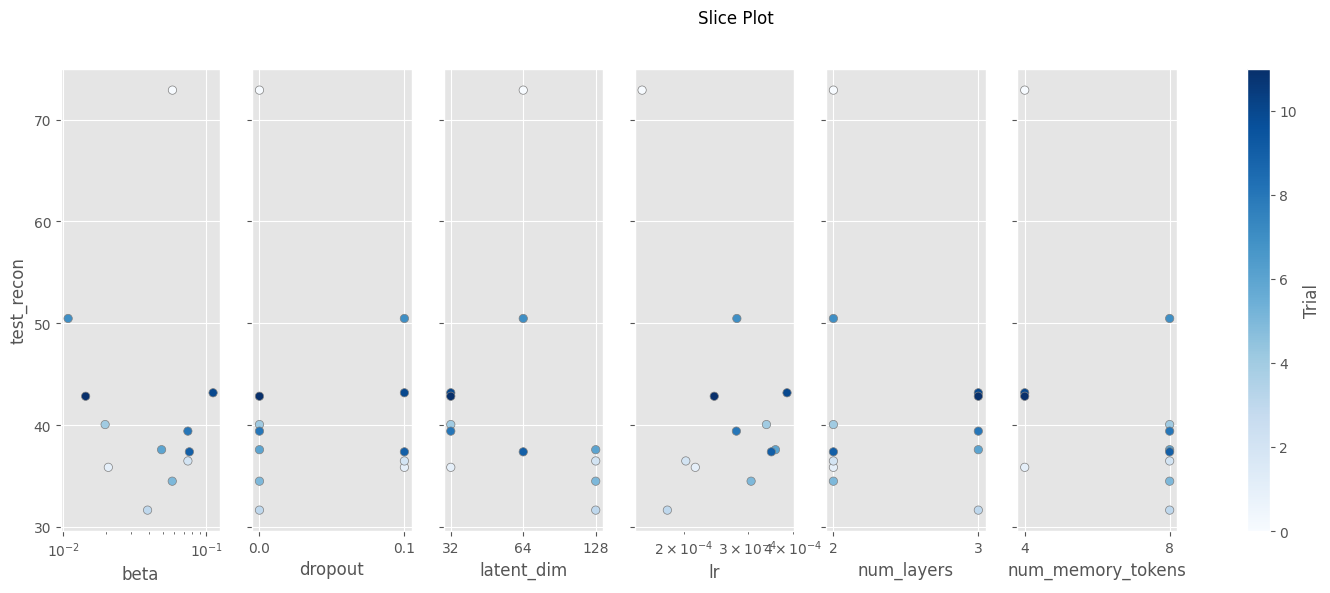

In [ ]:
plot_slice(tvae_study, params=['latent_dim', 'beta', 'lr', 'dropout', 'num_layers', 'num_memory_tokens'],
           target=lambda t: t.values[0], target_name='test_recon')
fig = plt.gcf()
fig.set_size_inches(18, 6)
plt.savefig('results/tvae_slice.png', dpi=150, bbox_inches='tight')

## Study 2: Downstream drift sensitivity

This is what makes the ablation more than a generic hyperparameter sweep — it shows
the choice matters for the epidemiological application. We take the best and worst
configs from Study 1, retrain them, compute drift scores, and correlate with CDC
hospitalisation rates.

In [ ]:
# pick the best and worst configs by reconstruction loss from the Pareto front
valid_trials = [t for t in tvae_study.trials if t.values[0] != float('inf')]
sorted_by_recon = sorted(valid_trials, key=lambda t: t.values[0])
best_trial = sorted_by_recon[0]
worst_trial = sorted_by_recon[-1]

configs = {
    "best": {
        "latent_dim": best_trial.params.get("latent_dim"),
        "beta": best_trial.params.get("beta"),
        "lr": best_trial.params.get("lr"),
        "d_model": best_trial.user_attrs.get("d_model", best_trial.params.get("d_model")),
        "num_layers": best_trial.user_attrs.get("num_layers", best_trial.params.get("num_layers")),
        "dim_feedforward": best_trial.user_attrs.get("dim_feedforward", best_trial.params.get("dim_feedforward")),
        "num_memory_tokens": best_trial.user_attrs.get("num_memory_tokens", best_trial.params.get("num_memory_tokens")),
        "dropout": best_trial.params.get("dropout"),
        "test_recon": best_trial.user_attrs.get("test_recon"),
        "test_kl": best_trial.user_attrs.get("test_kl"),
        "silhouette": best_trial.user_attrs.get("silhouette"),
    },
    "worst": {
        "latent_dim": worst_trial.params.get("latent_dim"),
        "beta": worst_trial.params.get("beta"),
        "lr": worst_trial.params.get("lr"),
        "d_model": worst_trial.user_attrs.get("d_model", worst_trial.params.get("d_model")),
        "num_layers": worst_trial.user_attrs.get("num_layers", worst_trial.params.get("num_layers")),
        "dim_feedforward": worst_trial.user_attrs.get("dim_feedforward", worst_trial.params.get("dim_feedforward")),
        "num_memory_tokens": worst_trial.user_attrs.get("num_memory_tokens", worst_trial.params.get("num_memory_tokens")),
        "dropout": worst_trial.params.get("dropout"),
        "test_recon": worst_trial.user_attrs.get("test_recon"),
        "test_kl": worst_trial.user_attrs.get("test_kl"),
        "silhouette": worst_trial.user_attrs.get("silhouette"),
    },
}

print("Best config: ", configs["best"])
print("Worst config:", configs["worst"])

Best config:  {'latent_dim': 128, 'beta': 0.03890446796113974, 'lr': 0.00017981813007388224, 'd_model': 128, 'num_layers': 3, 'dim_feedforward': 512, 'num_memory_tokens': 8, 'dropout': 0.0, 'test_recon': 31.663840994670736, 'test_kl': 71.89686092624099, 'silhouette': -0.10903273522853851}
Worst config: {'latent_dim': 64, 'beta': 0.058094985386619696, 'lr': 0.00015305926024417372, 'd_model': 64, 'num_layers': 2, 'dim_feedforward': 256, 'num_memory_tokens': 4, 'dropout': 0.0, 'test_recon': 72.88853246659828, 'test_kl': 106.8166007806245, 'silhouette': -0.23804964125156403}


In [ ]:
# retrain best and worst configs to get models we can extract latents from

drift_models = {}

for label, cfg in configs.items():
    print(
        f'\nTraining {label}: '
        f'latent_dim={cfg["latent_dim"]}, '
        f'beta={cfg["beta"]:.3f}, '
        f'd_model={cfg["d_model"]}, '
        f'num_layers={cfg["num_layers"]}'
    )


    model = TransformerVAE(
        input_dim=INPUT_DIM,
        d_model=cfg["d_model"],
        latent_dim=cfg["latent_dim"],
        seq_length=SEQ_LENGTH,
        nhead=TVAE_FIXED["nhead"],
        num_layers=cfg["num_layers"],
        dim_feedforward=cfg["dim_feedforward"],
        dropout=cfg["dropout"],
        num_memory_tokens=cfg["num_memory_tokens"],
    ).to(device)

    criterion = VAE_Loss(beta=cfg["beta"])

    optimiser = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=TVAE_FIXED.get("weight_decay", 1e-2),
    )

    model, history = VAE_train(
        model,
        h1n1_train,
        h1n1_test,
        criterion,
        optimiser,
        device,
        epochs=80,
        patience=10,
        anneal_epochs=10,
        save_every=50,
    )

    drift_models[label] = model
    print(f'  Final test recon: {history["test_recon_loss"][-1]:.4f}')


Training best: latent_dim=128, beta=0.039, d_model=128, num_layers=3


Training:  62%|██████▎   | 50/80 [22:02<12:12, 24.41s/epoch, avg loss=31.3492]

  Checkpoint saved at epoch 50 -> checkpoint.pt


Training: 100%|██████████| 80/80 [34:14<00:00, 25.69s/epoch, avg loss=25.9149]


  Final test recon: 25.0531

Training worst: latent_dim=64, beta=0.058, d_model=64, num_layers=2


Training:  62%|██████▎   | 50/80 [10:55<06:02, 12.08s/epoch, avg loss=73.5452]

  Checkpoint saved at epoch 50 -> checkpoint.pt


Training: 100%|██████████| 80/80 [16:57<00:00, 12.71s/epoch, avg loss=56.4311]

  Final test recon: 52.5882


In [ ]:

raw = load_dataset('sidms/AML', 'H1N1_drift')


encoder = dna_one_hot()
ds = raw['train'].map(encoder, batched=True, num_proc=4, remove_columns=['sequence'])
ds.set_format(type='torch', columns=['input_ids', 'year'], output_all_columns=True)

h1n1_drift = DataLoader(ds, batch_size=512, shuffle=False,
                         collate_fn=_collate_mixed, num_workers=4, pin_memory=True)

Map (num_proc=4): 100%|██████████| 25760/25760 [00:04<00:00, 5552.32 examples/s]


In [ ]:
# extract latents and compute drift scores for both configs
drift_results = {}
for label, model in drift_models.items():
    result = extract_latents(model, h1n1_drift, device=device)
    latents, years = result[0], result[1]
    months = result[3] if len(result) > 3 else None
    seasons = result[4] if len(result) > 4 else None
    drift_df = compute_drift_scores(latents, years, months=months,
                                    seasons=seasons, max_per_season = 30)
    drift_results[label] = drift_df

drift_results['best']

,season,drift_raw,n_sequences,centroid,drift_norm
0,2009-10,2.716072,644,"[-0.44470215, 0.22959392, 0.29696858, 0.401904...",0.500000
1,2010-11,4.858945,134,"[-0.4717069, -0.010766601, -0.551827, 0.462048...",1.000000
2,2011-12,4.967112,42,"[-1.0307658, 0.36813152, -0.79688317, 0.194154...",1.000000
3,2012-13,3.573186,34,"[-0.67799073, 0.071614586, -0.7230143, 0.34991...",0.380764
4,2013-14,7.113770,112,"[0.0063194274, -0.4838084, -0.4408671, 0.92369...",1.000000
5,2014-15,6.699463,140,"[0.49733174, -0.35328153, -0.7335113, 0.493067...",0.905790
6,2015-16,7.599764,1524,"[0.044995118, 0.55084383, 0.07021078, 0.313948...",1.000000
7,2016-17,1.595063,548,"[-0.11603089, 0.48016766, -0.17890587, 0.23637...",0.000000
8,2017-18,5.652619,1173,"[-0.3426239, 0.13374887, -0.8304688, 0.1223953...",0.675730
9,2018-19,3.397439,2509,"[-0.44354045, 0.21783854, -0.857963, 0.0613657...",0.300161


In [ ]:
# load CDC hospitalisation data
HF_REPO = 'sidms/AML'
HF_BASE = f'https://huggingface.co/datasets/{HF_REPO}/resolve/main'
season_summary = pd.read_csv(f'{HF_BASE}/cdc_data/season_summary.csv')
hosp = season_summary[['season', 'hosp_rate_overall']].dropna(subset=['hosp_rate_overall'])
print(f'Hospitalisation data: {len(hosp)} seasons')
hosp.head()

Hospitalisation data: 17 seasons


,season,hosp_rate_overall
12,2009-10,29.3
13,2010-11,21.5
14,2011-12,8.7
15,2012-13,44.0
16,2013-14,35.1


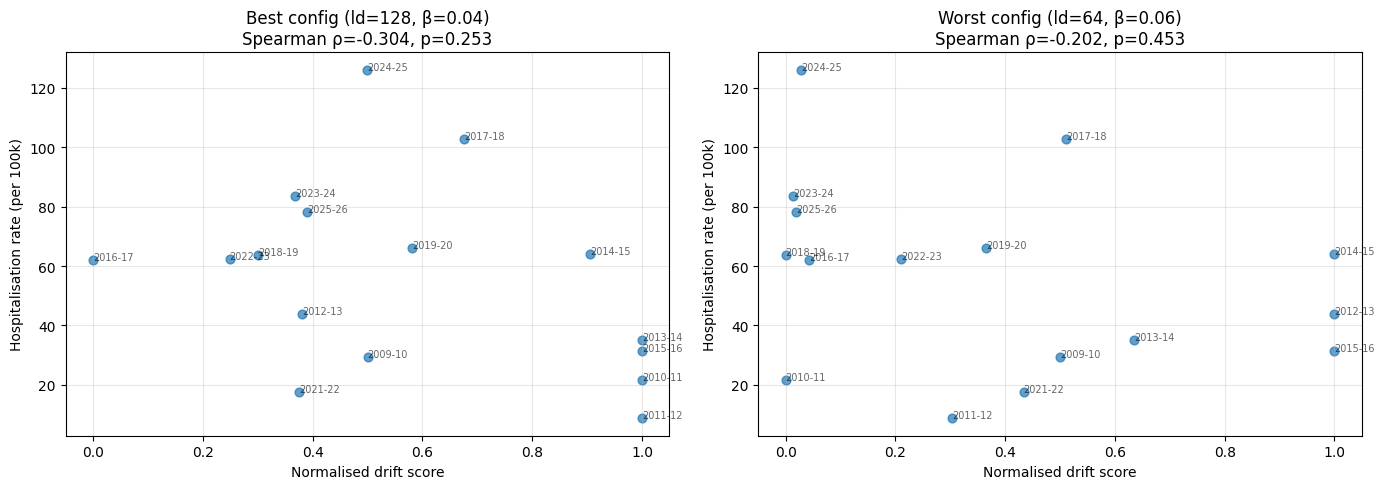

In [ ]:
# compute Spearman correlation between drift and hospitalisation for each config

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, drift_df) in zip(axes, drift_results.items()):
    merged = drift_df.merge(hosp, on='season', how='inner')
    # exclude 2020-21 (COVID disruption)
    merged = merged[merged['season'] != '2020-21']

    rho, pval = spearmanr(merged['drift_norm'], merged['hosp_rate_overall'])

    ax.scatter(merged['drift_norm'], merged['hosp_rate_overall'], s=40, alpha=0.7)
    for _, row in merged.iterrows():
        ax.annotate(row['season'], (row['drift_norm'], row['hosp_rate_overall']),
                    fontsize=7, alpha=0.6)
    cfg = configs[label]
    ax.set_title(f"{label.title()} config (ld={cfg['latent_dim']}, β={cfg['beta']:.2f})\n"
                 f"Spearman ρ={rho:.3f}, p={pval:.3f}")
    ax.set_xlabel('Normalised drift score')
    ax.set_ylabel('Hospitalisation rate (per 100k)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/drift_sensitivity_best_vs_worst.png', dpi=150, bbox_inches='tight')
plt.show()

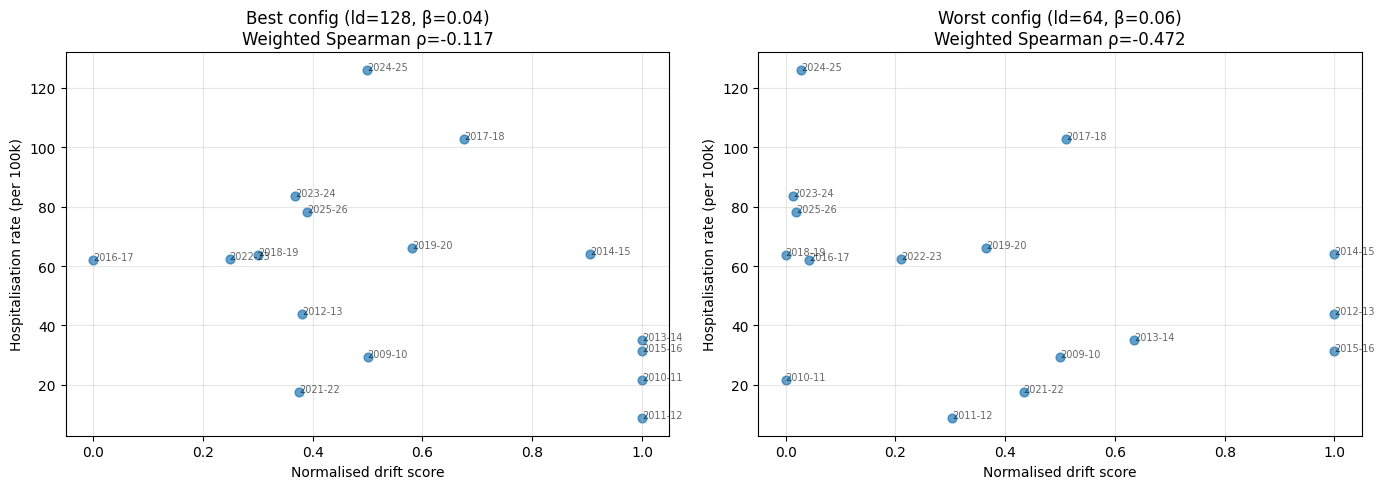

In [ ]:
# weighted Spearman correlation between drift and hospitalisation for each config

def weighted_corr(x, y, w):
    mx = np.average(x, weights=w)
    my = np.average(y, weights=w)
    cov = np.average((x - mx) * (y - my), weights=w)
    sx = np.sqrt(np.average((x - mx)**2, weights=w))
    sy = np.sqrt(np.average((y - my)**2, weights=w))
    return cov / (sx * sy)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, drift_df) in zip(axes, drift_results.items()):
    merged = drift_df.merge(hosp, on='season', how='inner')
    merged = merged[merged['season'] != '2020-21']

    ranks_drift = rankdata(merged['drift_norm'])
    ranks_hosp = rankdata(merged['hosp_rate_overall'])
    weights = merged['n_sequences'].values

    rho_w = weighted_corr(ranks_drift, ranks_hosp, weights)

    ax.scatter(merged['drift_norm'], merged['hosp_rate_overall'], s=40, alpha=0.7)
    for _, row in merged.iterrows():
        ax.annotate(row['season'], (row['drift_norm'], row['hosp_rate_overall']),
                    fontsize=7, alpha=0.6)
    cfg = configs[label]
    ax.set_title(f"{label.title()} config (ld={cfg['latent_dim']}, β={cfg['beta']:.2f})\n"
                 f"Weighted Spearman ρ={rho_w:.3f}")
    ax.set_xlabel('Normalised drift score')
    ax.set_ylabel('Hospitalisation rate (per 100k)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/drift_sensitivity_best_vs_worst.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:


def partial_spearman(x, y, z):
    """Spearman correlation between x and y, controlling for z."""
    rx, ry, rz = rankdata(x), rankdata(y), rankdata(z)
    rho_xz = np.corrcoef(rx, rz)[0, 1]
    rho_yz = np.corrcoef(ry, rz)[0, 1]
    res_x = rx - rho_xz * rz
    res_y = ry - rho_yz * rz
    return np.corrcoef(res_x, res_y)[0, 1]

# check if n_sequences is itself correlated with hospitalisation
rho_confound, p_confound = spearmanr(merged['n_sequences'], merged['hosp_rate_overall'])
print(f'n_sequences vs hosp: ρ={rho_confound:.3f}, p={p_confound:.3f}')

# partial Spearman: drift vs hospitalisation, controlling for n_sequences
rho_partial = partial_spearman(
    merged['drift_norm'], merged['hosp_rate_overall'], merged['n_sequences']
)
print(f'Partial Spearman (controlling n_sequences): ρ={rho_partial:.3f}')

n_sequences vs hosp: ρ=0.662, p=0.005
Partial Spearman (controlling n_sequences): ρ=0.112


In [ ]:
from statsmodels.tsa.ar_model import AutoReg

drift_raw = drift_df['drift_raw'].values
model = AutoReg(drift_raw, lags=1).fit()
residuals = model.resid  # ε_t — the surprise component
beta_ar = model.params[1]
print(f'AR(1) β={beta_ar:.3f}')

AR(1) β=0.169


In [ ]:
from huggingface_hub import upload_folder

upload_folder(
    folder_path="results",
    repo_id="sidms/AML",
    repo_type="dataset",
    path_in_repo = "sweep_results_tvae"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            
New Data Upload               : |          |  0.00B /  0.00B            

  ...e_contour_latent_beta.png: 100%|██████████| 88.5kB / 88.5kB            


  ...vae_param_importances.png: 100%|██████████| 54.4kB / 54.4kB            



  ...lts/optuna_study_tvae.pkl: 100%|██████████| 18.8kB / 18.8kB            

  ...e_contour_latent_beta.png: 100%|██████████| 88.5kB / 88.5kB            


  ...vae_param_importances.png: 100%|██████████| 54.4kB / 54.4kB            



Processing Files (3 / 3)      :  45%|████▌     |  162kB /  356kB,   ???B/s  




  .../results/tvae_history.png: 100%|██████████| 32.5kB / 32.5kB            

  ...e_contour_latent_beta.png: 100%|██████████| 88.5kB / 88.5kB            


  ...vae_param_importances.png: 100%|██████████| 54.4kB / 54.4kB            



  ...lts/optuna_study_tvae.pkl: 100%|██████████| 18.8kB / 18.8kB            




Processing Files (4 / 4)      :  55%|█████▍    |  194kB / 

CommitInfo(commit_url='https://huggingface.co/datasets/sidms/AML/commit/ad4af392c08c1d39654ff14813f80cd4c098f29b', commit_message='Upload folder using huggingface_hub', commit_description='', oid='ad4af392c08c1d39654ff14813f80cd4c098f29b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/sidms/AML', endpoint='https://huggingface.co', repo_type='dataset', repo_id='sidms/AML'), pr_revision=None, pr_num=None)

In [4]:
TVAE_SEARCH_SPACE_STAGE2 = {
    "latent_dim": [64, 128],
    "beta": (0.02, 0.08),
    "lr": (1.6e-4, 3.2e-4),
    "dropout": [0.0, 0.1],
    "d_model": [128],
    "num_layers": [2, 3],
    "num_memory_tokens": [8],
}

In [ ]:
tvae_study2 = run_tvae_sweep(
    h1n1_train,
    h1n1_test,
    input_dim=INPUT_DIM,
    seq_length=SEQ_LENGTH,
    device=device,
    n_trials=10,
    search_space=TVAE_SEARCH_SPACE_STAGE2,

)
joblib.dump(tvae_study2, 'results/optuna_study_tvae2.pkl')

In [6]:
# results table — filter out diverged trials
rows = []
for t in tvae_study2.trials:
    if t.values[0] == float('inf'):
        continue
    beta_val = t.params.get('beta', np.nan)
    test_kl = t.user_attrs.get('test_kl', np.nan)
    test_recon = t.user_attrs.get('test_recon', t.values[0])

    rows.append({
        'trial': t.number,
        'latent_dim': t.params.get('latent_dim', t.user_attrs.get('latent_dim')),
        'beta': round(beta_val, 3) if not np.isnan(beta_val) else np.nan,
        'd_model': t.user_attrs.get('d_model', t.params.get('d_model')),
        'num_layers': t.user_attrs.get('num_layers', t.params.get('num_layers')),
        'dim_feedforward': t.user_attrs.get('dim_feedforward', t.params.get('dim_feedforward')),
        'num_memory_tokens': t.user_attrs.get('num_memory_tokens', t.params.get('num_memory_tokens')),
        'dropout': t.params.get('dropout'),
        'lr': t.params.get('lr'),
        'test_recon': round(test_recon, 4) if not np.isnan(test_recon) else np.nan,
        'silhouette': round(-t.values[1], 4),
        'test_kl': round(test_kl, 4) if not np.isnan(test_kl) else np.nan,
        'kl_collapsed': t.user_attrs.get('kl_collapsed'),
        'epochs': t.user_attrs.get('epochs_trained'),
        'test_loss': round(test_recon + beta_val * test_kl, 4)
                    if not (np.isnan(test_recon) or np.isnan(beta_val) or np.isnan(test_kl))
                    else np.nan,
    })
df_tvae2 = pd.DataFrame(rows).sort_values('test_recon')
df_tvae2.to_csv('results/optuna_tvae_results2.csv', index=False)
df_tvae2

,trial,latent_dim,beta,d_model,num_layers,dim_feedforward,num_memory_tokens,dropout,lr,test_recon,silhouette,test_kl,kl_collapsed,epochs,test_loss
3,3,128,0.045,128,3,512,8,0.0,0.000165,31.8262,-0.0295,68.9539,False,40,34.9614
5,5,128,0.029,128,3,512,8,0.1,0.000253,32.4673,-0.1215,59.4987,False,40,34.1708
8,8,128,0.022,128,3,512,8,0.0,0.000317,33.0262,-0.2317,71.0166,False,40,34.6011
9,9,128,0.058,128,3,512,8,0.0,0.000168,34.5992,-0.1518,47.9769,False,40,37.3944
1,1,128,0.063,128,3,512,8,0.1,0.000185,35.7541,-0.2010,39.2335,False,40,38.2422
7,7,128,0.034,128,3,512,8,0.0,0.000193,35.8358,-0.1854,57.1967,False,40,37.7965
4,4,128,0.031,128,2,512,8,0.0,0.000171,39.0261,-0.3397,99.2345,False,40,42.0536
6,6,64,0.074,128,2,512,8,0.1,0.000298,44.7435,-0.1410,24.3563,False,40,46.5352
2,2,128,0.047,128,2,512,8,0.1,0.000176,45.0242,-0.3476,55.3558,False,40,47.6098
0,0,128,0.025,128,2,512,8,0.1,0.000178,48.2341,-0.1376,61.3840,False,40,49.7582


In [8]:
from huggingface_hub import upload_file

upload_file(
    path_or_fileobj='results/optuna_study_tvae2.pkl',
    repo_id="sidms/AML",
    repo_type="dataset",
    path_in_repo = "sweep_results_tvae/optuna_study_tvae2.pkl"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            
New Data Upload               : |          |  0.00B /  0.00B            

  ...ts/optuna_study_tvae2.pkl: 100%|██████████| 17.8kB / 17.8kB            

Processing Files (1 / 1)      : 100%|██████████| 17.8kB / 17.8kB, 17.8kB/s  
New Data Upload               : 100%|██████████| 17.8kB / 17.8kB, 17.8kB/s  

  ...ts/optuna_study_tvae2.pkl: 100%|██████████| 17.8kB / 17.8kB            

  ...ts/optuna_study_tvae2.pkl: 100%|██████████| 17.8kB / 17.8kB            

  ...ts/optuna_study_tvae2.pkl: 100%|██████████| 17.8kB / 17.8kB            

  ...ts/optuna_study_tvae2.pkl: 100%|██████████| 17.8kB / 17.8kB            

  ...ts/optuna_study_tvae2.pkl: 100%|██████████| 17.8kB / 17.8kB            

Processing Files (1 / 1)      : 100%|██████████| 17.8kB / 17.8kB, 8.91kB/s  
New Data Upload               : 100%|██████████| 17.8kB / 17.8kB, 8.91kB/s  
  ...ts/optuna_study_tvae2.pkl: 100%|██████████| 17.8kB / 17.8kB            

CommitInfo(commit_url='https://huggingface.co/datasets/sidms/AML/commit/7316928e2b2e5cefe4a8e21d20d4f43335049f8a', commit_message='Upload sweep_results_tvae/optuna_study_tvae2.pkl with huggingface_hub', commit_description='', oid='7316928e2b2e5cefe4a8e21d20d4f43335049f8a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/sidms/AML', endpoint='https://huggingface.co', repo_type='dataset', repo_id='sidms/AML'), pr_revision=None, pr_num=None)